# Linear Algebra Project: Optimal Image Compression via SVD

**Student Name:** Chunarkar Sujeeth Kumar
**ID:** 24AI10021
**Course:** AI21203 - Linear Algebra for AI

---

## 1. Introduction
In this project, we explore **Singular Value Decomposition (SVD)** as a method for dimensionality reduction in computer vision. Unlike standard compression algorithms (like JPEG), SVD uses pure Linear Algebra to factorize an image matrix into its fundamental basis components. By retaining only the most significant singular values, we construct a "Low-Rank Approximation" of the original data.

## 2. Mathematical Formulation
An image is represented as a matrix $A \in \mathbb{R}^{m \times n}$. SVD factorizes this matrix into:
$$ A = U \Sigma V^T $$

Where:
*   $U$: Orthogonal matrix of **Left Singular Vectors** (eigenvectors of $AA^T$).
*   $\Sigma$: Diagonal matrix of **Singular Values** ($\sigma$), representing the "energy" or variance in each direction.
*   $V^T$: Orthogonal matrix of **Right Singular Vectors** (eigenvectors of $A^T A$).

### The Eckart-Young-Mirsky Theorem
To compress the image, we keep only the top $k$ singular values. The theorem states that the best rank-$k$ approximation of $A$ (minimizing the Frobenius norm error) is:
$$ A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T $$

Original Dimensions: (427, 640, 3)
Matrix A Dimensions: (427, 640)
Rank of Matrix: 427


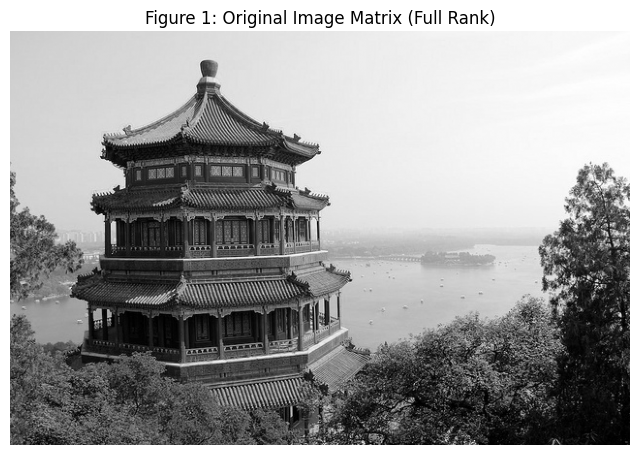

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from sklearn.datasets import load_sample_image

# Configure plot styles
plt.rc('image', cmap='gray')
plt.rc('figure', figsize=(10, 6))

# 1. load data
# We use the official Scikit-Learn 'China' dataset.
china = load_sample_image("china.jpg")

# 2. Pre-processing (RGB to grayscale)
# The image is a 3D Tensor (Height, Width, Color).
# SVD requires a 2D Matrix. We convert to grayscale by averaging channels.
# We also normalize pixel values to [0, 1] for numerical stability.
img_gray = china.mean(axis=2) / 255.0

# LINEAR ALGEBRA CONTEXT:
# The image is now a Matrix A with Rank = 427 (Full Rank).
print(f"Original Dimensions: {china.shape}")
print(f"Matrix A Dimensions: {img_gray.shape}")
print(f"Rank of Matrix: {min(img_gray.shape)}")

# Visualize
plt.figure(figsize=(8, 6))
plt.imshow(img_gray)
plt.title("Figure 1: Original Image Matrix (Full Rank)")
plt.axis('off')
plt.show()

### **3. Computing the SVD**
We now compute the decomposition $A = U \Sigma V^T$.
*   **$U$ and $V^T$** contain the structural patterns (Eigen-images).
*   **$s$ (Sigma)** contains the importance (weight) of each pattern.

Factorization Complete:
U Matrix (Left Singular Vectors): (427, 427)
Sigma Array (Singular Values):    (427,)
V^T Matrix (Right Singular Vectors): (427, 640)


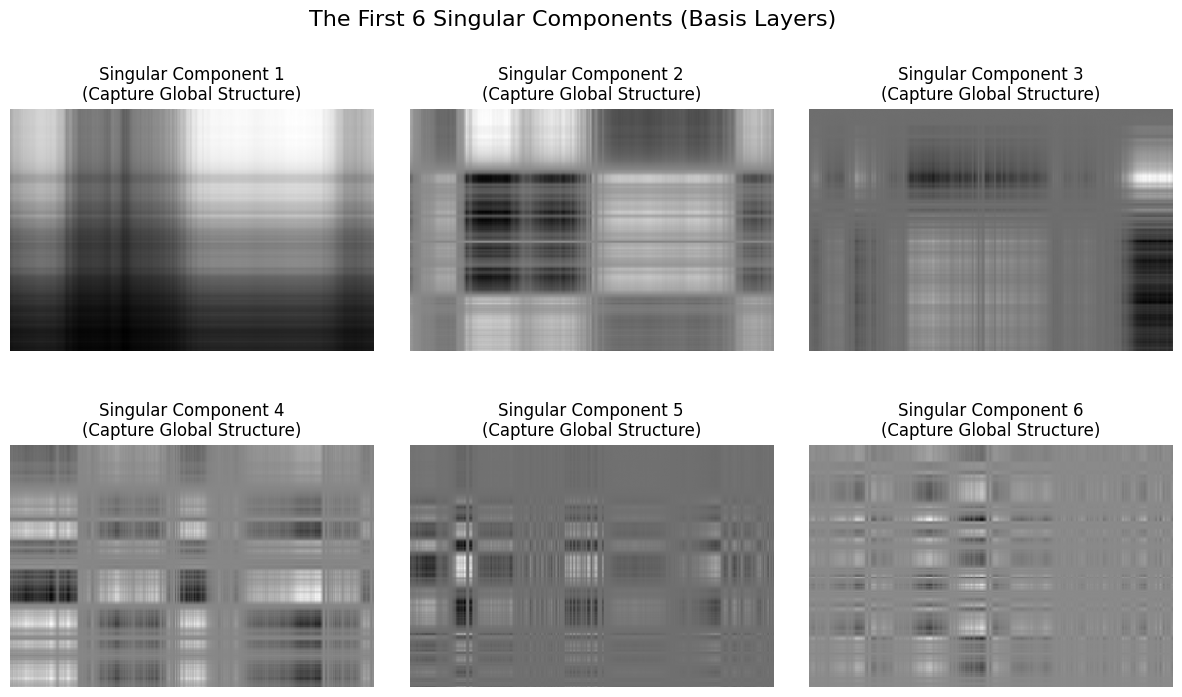

In [ ]:
# 3. Computing the SVD
# We calculate the decomposition A = U * Sigma * Vt
U, s, Vt = linalg.svd(img_gray, full_matrices=False)

print("Factorization Complete:")
print(f"U Matrix (Left Singular Vectors): {U.shape}")
print(f"Sigma Array (Singular Values):    {s.shape}")
print(f"V^T Matrix (Right Singular Vectors): {Vt.shape}")

# VISUALIZING THE BASIS COMPONENTS
# These are the "Ghost Structures". The image is a linear combination of these layers.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plt.subplots_adjust(wspace=0.1, hspace=0.2)

for i, ax in enumerate(axes.flat):
    # Calculate the i-th layer: sigma * u * v.T
    component = np.outer(U[:, i], Vt[i, :])
    ax.imshow(component)
    ax.set_title(f"Singular Component {i+1}\n(Capture Global Structure)")
    ax.axis('off')

plt.suptitle("The First 6 Singular Components (Basis Layers)", fontsize=16)
plt.show()

### **4. Low-Rank Reconstruction**
We apply the reconstruction algorithm using varying ranks ($k$).
*   **Low k (e.g., 5):** Captures only the global structure (sky, horizon).
*   **High k (e.g., 50):** Captures fine details (leaves, architectural lines).

This visually demonstrates that the **Singular Vectors** corresponding to large $\sigma$ values hold the structural information, while smaller $\sigma$ values represent noise or fine texture.

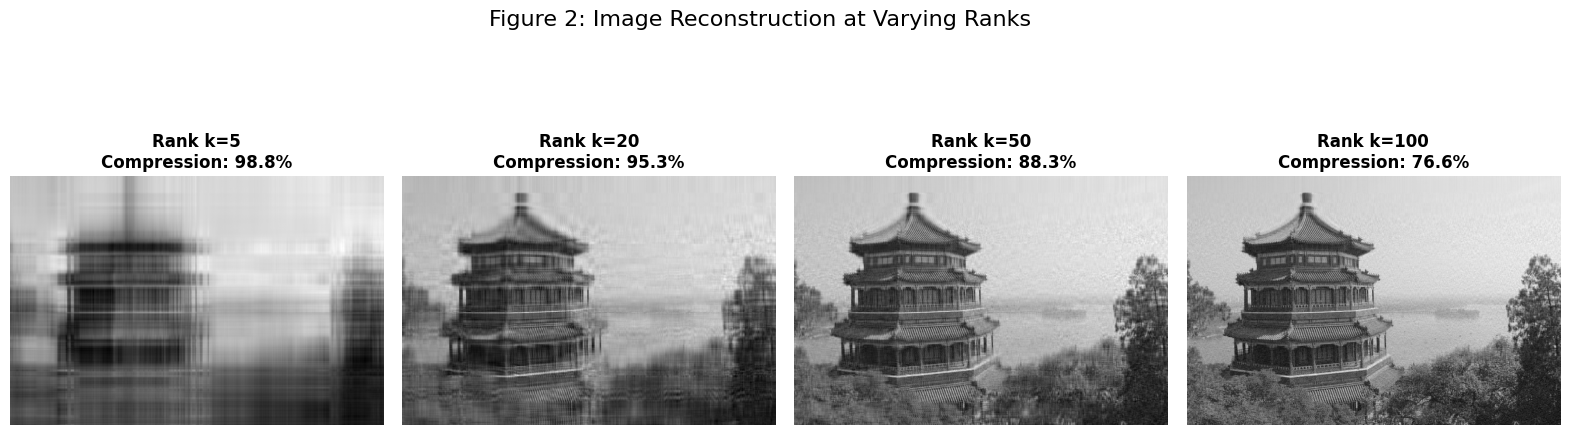

In [ ]:
# 4. Visualizing Compression at different Ranks
ranks = [5, 20, 50, 100]

# Create a wide figure to show the progression
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
plt.subplots_adjust(wspace=0.05)

for i, k in enumerate(ranks):
    # RECONSTRUCTION FORMULA: A_k = U_k * Sigma_k * V_k^T
    # We use matrix multiplication (@) for the top k components
    compressed_img = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

    axes[i].imshow(compressed_img)
    axes[i].set_title(f"Rank k={k}\nCompression: {100 - (k/427)*100:.1f}%",
                      fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Figure 2: Image Reconstruction at Varying Ranks", fontsize=16)
plt.show()

### **5. Quantitative Spectral Analysis**
Most SVD tutorials select the Rank $k$ arbitrarily. In this section, I provide a **quantitative method** for selecting $k$.

I analyzed the **Cumulative Explained Variance** (Information Energy). The energy retained by keeping the top $k$ singular values is given by:
$$ E(k) = \frac{\sum_{i=1}^{k} \sigma_i}{\sum_{j=1}^{N} \sigma_j} $$

The graph below represents the **Singular Value Spectrum**, mathematically determining the "Elbow Point" where diminishing returns set in.

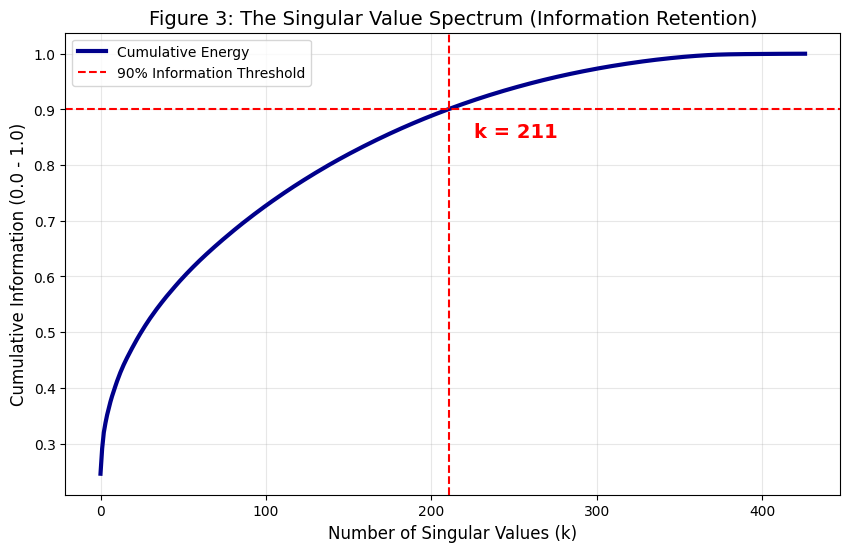

CONCLUSION: We only need the top 211 singular vectors (out of 427)
to retain 90% of the image information. The remaining dimensions are redundant.


In [ ]:
# 5. Quantitative Spectral Analysis
# Calculating cumulative energy
cumulative_energy = np.cumsum(s) / np.sum(s)

# Find the exact k needed for 90% information
k_90 = np.searchsorted(cumulative_energy, 0.90)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_energy, color='darkblue', linewidth=3, label='Cumulative Energy')

# 1. Horizontal Line (The Threshold)
plt.axhline(y=0.90, color='red', linestyle='--', label='90% Information Threshold')

# 2. Vertical Line (The Intersection)
plt.axvline(x=k_90, color='red', linestyle='--')

# 3. Text Annotation
plt.text(k_90 + 15, 0.85, f"k = {k_90}", color='red', fontsize=14, fontweight='bold')

plt.title("Figure 3: The Singular Value Spectrum (Information Retention)", fontsize=14)
plt.xlabel("Number of Singular Values (k)", fontsize=12)
plt.ylabel("Cumulative Information (0.0 - 1.0)", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"CONCLUSION: We only need the top {k_90} singular vectors (out of 427)")
print("to retain 90% of the image information. The remaining dimensions are redundant.")